# 07 - Model Comparison (GPT-5.5 vs QLoRA Qwen)

Phase 7.7. Consolidates the evidence from notebooks 05 (ROUGE + BERTScore) and 06 (LLM-as-judge — Accuracy / Completeness / Clarity / Safety) into a single 2-row comparison on the same 100-pair stratified test sample.

**No new LLM calls.** Merges `results/llm_generation_evaluation.csv` and `results/llm_judge_evaluation.csv`. If either is missing, run 05 / 06 first.

**The 8 reported columns (per model)**

- Surface similarity: **ROUGE-L (F1)**
- Semantic similarity: **BERTScore-F1** (PubMedBERT)
- Judge dimensions (0-10): **Accuracy**, **Completeness**, **Clarity**, **Safety**
- Operational: **Latency (s)** mean per call
- Plus: a **lift table** showing QLoRA Qwen's signed gap vs GPT-5.5 on each quality metric.

**Outputs**

- `results/model_comparison.csv` - merged per-row scores (200 rows × all metrics)
- `results/model_comparison.md` - overall + per-source breakdown + verdict
- `results/model_comparison_chart.png` - grouped bars across the 6 quality metrics (judge dims normalised to 0-1 for shared axis)


In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
GEN_CSV = RESULTS_DIR / "llm_generation_evaluation.csv"
JUDGE_CSV = RESULTS_DIR / "llm_judge_evaluation.csv"
OUT_CSV = RESULTS_DIR / "model_comparison.csv"
OUT_MD = RESULTS_DIR / "model_comparison.md"
OUT_PNG = RESULTS_DIR / "model_comparison_chart.png"

WARM = "#c47a4d"  # GPT-5.5
COOL = "#3b6e8f"  # QLoRA Qwen
MODELS = [
    {"name": "GPT-5.5", "color": WARM},
    {"name": "QLoRA Qwen", "color": COOL},
]

# Each entry: (column_in_df, display_name, native_max — used to normalise to 0-1 for the chart)
QUALITY_METRICS = [
    ("rougeL_f", "ROUGE-L", 1.0),
    ("bertscore_f1", "BERT-F1", 1.0),
    ("accuracy", "Accuracy", 10.0),
    ("completeness", "Completeness", 10.0),
    ("clarity", "Clarity", 10.0),
    ("safety", "Safety", 10.0),
]

## 1. Load + merge

Inner join on `(idx, source, model)`. The `question`, `reference`, `generated` columns are identical in both CSVs and only kept from the generation side (judge side is dropped to avoid `_x` / `_y` suffixes).


In [ ]:
if not GEN_CSV.exists():
    raise FileNotFoundError(f"{GEN_CSV} not found — run notebook 05 first.")
if not JUDGE_CSV.exists():
    raise FileNotFoundError(f"{JUDGE_CSV} not found — run notebook 06 first.")

GEN_KEEP = [
    "idx",
    "source",
    "model",
    "question",
    "reference",
    "generated",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "bertscore_p",
    "bertscore_r",
    "bertscore_f1",
    "latency_s",
]
JUDGE_KEEP = [
    "idx",
    "source",
    "model",
    "accuracy",
    "completeness",
    "clarity",
    "safety",
    "rationale",
    "judge_latency_s",
]

gen_df = pd.read_csv(GEN_CSV)[GEN_KEEP]
judge_df = pd.read_csv(JUDGE_CSV)[JUDGE_KEEP]

df = pd.merge(gen_df, judge_df, on=["idx", "source", "model"], how="inner")
df.to_csv(OUT_CSV, index=False, encoding="utf-8")

print(f"Generation rows: {len(gen_df)}")
print(f"Judge rows:      {len(judge_df)}")
print(f"Merged rows:     {len(df)}")
print(f"Models:          {sorted(df['model'].unique())}")

Generation rows: 200
Judge rows:      200
Merged rows:     200
Models:          ['GPT-5.5', 'QLoRA Qwen']


## 2. Overall summary (the 2-row headline table)


In [ ]:
summary = (
    df.groupby("model")
    .agg(
        n=("idx", "count"),
        rougeL=("rougeL_f", "mean"),
        bertF1=("bertscore_f1", "mean"),
        accuracy=("accuracy", "mean"),
        completeness=("completeness", "mean"),
        clarity=("clarity", "mean"),
        safety=("safety", "mean"),
        latency_s=("latency_s", "mean"),
    )
    .reindex([m["name"] for m in MODELS])
    .round(
        {
            "rougeL": 4,
            "bertF1": 4,
            "accuracy": 2,
            "completeness": 2,
            "clarity": 2,
            "safety": 2,
            "latency_s": 2,
        }
    )
)
summary

,n,rougeL,bertF1,accuracy,completeness,clarity,safety,latency_s
model,,,,,,,,
GPT-5.5,100,0.1877,0.8214,9.20,8.16,9.33,9.52,8.23
QLoRA Qwen,100,0.2095,0.8281,3.51,3.12,6.77,5.32,0.90


## 3. Lift: QLoRA Qwen vs GPT-5.5

Per quality metric: absolute difference (`QLoRA − GPT-5.5`) and relative difference as a percentage of the GPT-5.5 mean. Positive = QLoRA Qwen ahead; negative = GPT-5.5 ahead.


In [ ]:
lift_rows = []
for col, label, scale in QUALITY_METRICS:
    gpt = float(
        summary.loc[
            "GPT-5.5",
            (
                "rougeL"
                if col == "rougeL_f"
                else ("bertF1" if col == "bertscore_f1" else col)
            ),
        ]
    )
    qlo = float(
        summary.loc[
            "QLoRA Qwen",
            (
                "rougeL"
                if col == "rougeL_f"
                else ("bertF1" if col == "bertscore_f1" else col)
            ),
        ]
    )
    abs_diff = qlo - gpt
    rel_pct = (abs_diff / gpt * 100.0) if gpt else float("nan")
    lift_rows.append(
        {
            "metric": label,
            "GPT-5.5": round(gpt, 4),
            "QLoRA Qwen": round(qlo, 4),
            "abs_diff (QLoRA − GPT)": round(abs_diff, 4),
            "rel_pct": round(rel_pct, 1),
            "winner": (
                "QLoRA Qwen" if abs_diff > 0 else ("GPT-5.5" if abs_diff < 0 else "tie")
            ),
        }
    )
lift = pd.DataFrame(lift_rows)
lift

,metric,GPT-5.5,QLoRA Qwen,abs_diff (QLoRA − GPT),rel_pct,winner
0,ROUGE-L,0.1877,0.2095,0.0218,11.6,QLoRA Qwen
1,BERT-F1,0.8214,0.8281,0.0067,0.8,QLoRA Qwen
2,Accuracy,9.2000,3.5100,-5.6900,-61.8,GPT-5.5
3,Completeness,8.1600,3.1200,-5.0400,-61.8,GPT-5.5
4,Clarity,9.3300,6.7700,-2.5600,-27.4,GPT-5.5
5,Safety,9.5200,5.3200,-4.2000,-44.1,GPT-5.5


## 4. Per-source × model breakdown


In [ ]:
by_source = (
    df.groupby(["source", "model"])
    .agg(
        n=("idx", "count"),
        rougeL=("rougeL_f", "mean"),
        bertF1=("bertscore_f1", "mean"),
        accuracy=("accuracy", "mean"),
        completeness=("completeness", "mean"),
        clarity=("clarity", "mean"),
        safety=("safety", "mean"),
        latency_s=("latency_s", "mean"),
    )
    .round(
        {
            "rougeL": 4,
            "bertF1": 4,
            "accuracy": 2,
            "completeness": 2,
            "clarity": 2,
            "safety": 2,
            "latency_s": 2,
        }
    )
    .reset_index()
)
by_source

,source,model,n,rougeL,bertF1,accuracy,completeness,clarity,safety,latency_s
0,bioasq,GPT-5.5,17,0.2174,0.8333,9.47,8.82,9.59,9.76,11.50
1,bioasq,QLoRA Qwen,17,0.1995,0.8325,4.47,3.41,6.65,6.53,0.69
2,drugbank-description,GPT-5.5,17,0.2223,0.8269,9.47,8.41,9.35,9.87,6.22
3,drugbank-description,QLoRA Qwen,17,0.2682,0.8401,2.82,3.41,7.06,5.00,0.98
4,drugbank-indication,GPT-5.5,17,0.1970,0.8271,9.29,8.18,9.47,9.31,5.88
5,drugbank-indication,QLoRA Qwen,17,0.2098,0.8265,3.35,3.12,6.82,4.41,0.88
6,drugbank-mechanism_of_action,GPT-5.5,17,0.2023,0.8300,9.47,8.24,9.59,9.75,6.81
7,drugbank-mechanism_of_action,QLoRA Qwen,17,0.1830,0.8198,2.47,2.41,6.24,4.53,0.95
8,drugbank-side_effects,GPT-5.5,16,0.0939,0.7963,8.38,7.44,8.94,8.88,7.38
9,drugbank-side_effects,QLoRA Qwen,16,0.1673,0.8184,3.38,2.88,6.62,4.50,1.04


## 5. Headline chart - 6 quality metrics × 2 models

Judge dimensions (Accuracy / Completeness / Clarity / Safety) are divided by 10 to share a 0-1 axis with ROUGE-L and BERT-F1. Value labels show the **native** scale (judge dims as `x.x/10`, surface metrics as `0.xxxx`) so the table-level numbers remain visible.


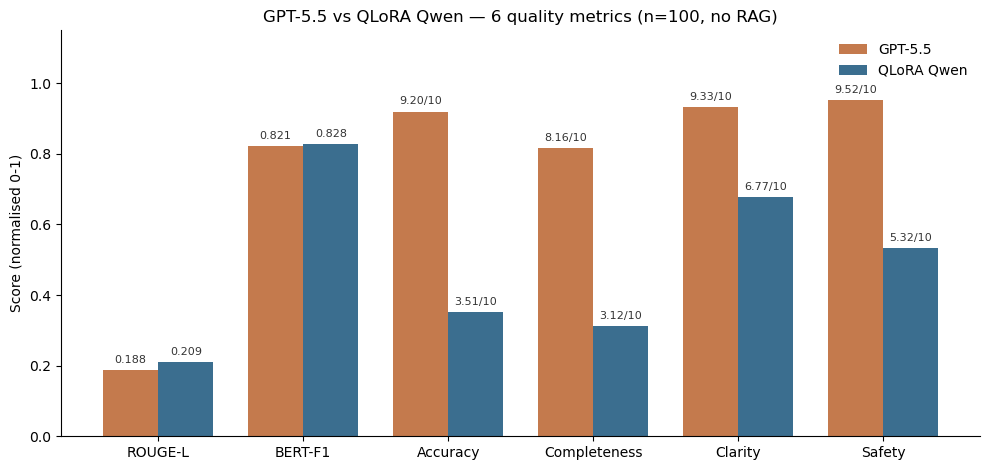

In [ ]:
labels = [label for _, label, _ in QUALITY_METRICS]
x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 4.8))
for offset, m in zip([-w / 2, w / 2], MODELS):
    norm_vals = []
    native_vals = []
    for col, label, scale in QUALITY_METRICS:
        v = float(df[df["model"] == m["name"]][col].mean())
        native_vals.append(v)
        norm_vals.append(v / scale)
    ax.bar(
        x + offset, norm_vals, w, color=m["color"], edgecolor="none", label=m["name"]
    )
    for xi, v, scale in zip(
        x + offset, native_vals, [s for _, _, s in QUALITY_METRICS]
    ):
        txt = f"{v:.2f}/10" if scale == 10.0 else f"{v:.3f}"
        ax.text(xi, (v / scale) + 0.02, txt, ha="center", fontsize=8, color="#333")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score (normalised 0-1)")
ax.set_ylim(0, 1.15)
ax.set_title("GPT-5.5 vs QLoRA Qwen — 6 quality metrics (n=100, no RAG)")
ax.legend(loc="upper right", frameon=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_PNG, dpi=150)
plt.show()

## 6. Verdict

A short qualitative interpretation, derived from the lift table. Surface-metric wins for QLoRA are framed as template-substitution skill (cf. memory: `learning_qlora_template_substitution`); judge wins for GPT-5.5 are framed as semantic / factual correctness on out-of-template prompts.


In [ ]:
def metric_winner(metric_label: str) -> tuple[str, float]:
    row = lift[lift["metric"] == metric_label].iloc[0]
    return row["winner"], float(row["rel_pct"])


for metric_label in [label for _, label, _ in QUALITY_METRICS]:
    winner, rel = metric_winner(metric_label)
    sign = "+" if rel >= 0 else ""
    print(f"{metric_label:<13}  winner = {winner:<11}  Δ(QLoRA−GPT) = {sign}{rel:.1f}%")

surface_winner = max(
    ["ROUGE-L", "BERT-F1"], key=lambda l: lift[lift["metric"] == l]["rel_pct"].values[0]
)
judge_dims = ["Accuracy", "Completeness", "Clarity", "Safety"]
judge_winners = [metric_winner(d)[0] for d in judge_dims]
judge_summary = ", ".join(f"{d}: {w}" for d, w in zip(judge_dims, judge_winners))

gpt_lat = float(summary.loc["GPT-5.5", "latency_s"])
qlora_lat = float(summary.loc["QLoRA Qwen", "latency_s"])
print()
print("Operational:")
print(
    f"  Latency: GPT-5.5 = {gpt_lat:.2f}s · QLoRA Qwen = {qlora_lat:.2f}s · QLoRA is ~{gpt_lat / max(qlora_lat, 1e-6):.1f}× faster"
)
print()
print(f"Judge-dimension winners: {judge_summary}")

ROUGE-L        winner = QLoRA Qwen   Δ(QLoRA−GPT) = +11.6%
BERT-F1        winner = QLoRA Qwen   Δ(QLoRA−GPT) = +0.8%
Accuracy       winner = GPT-5.5      Δ(QLoRA−GPT) = -61.8%
Completeness   winner = GPT-5.5      Δ(QLoRA−GPT) = -61.8%
Clarity        winner = GPT-5.5      Δ(QLoRA−GPT) = -27.4%
Safety         winner = GPT-5.5      Δ(QLoRA−GPT) = -44.1%

Operational:
  Latency: GPT-5.5 = 8.23s · QLoRA Qwen = 0.90s · QLoRA is ~9.1× faster

Judge-dimension winners: Accuracy: GPT-5.5, Completeness: GPT-5.5, Clarity: GPT-5.5, Safety: GPT-5.5


## 7. Write Markdown report


In [9]:
lines = [
    "# Model Comparison — GPT-5.5 vs QLoRA Qwen",
    "",
    f"- **Run date**: {time.strftime('%Y-%m-%d %H:%M:%S')}",
    "- **Sources**: `results/llm_generation_evaluation.csv` (ROUGE + BERTScore + latency) merged with `results/llm_judge_evaluation.csv` (4-dim LLM-judge)",
    f"- **Rows**: {len(df)} (= {df['idx'].nunique()} test pairs × {df['model'].nunique()} models)",
    "- **Setup**: raw generation, no RAG, no MASS-RAG; identical system prompt for both models (see notebook 05)",
    "",
    "## Overall (2-row headline)",
    "",
    "| Model | n | ROUGE-L | BERT-F1 | Accuracy | Completeness | Clarity | Safety | Latency (s) |",
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for m in MODELS:
    r = summary.loc[m["name"]]
    lines.append(
        f"| {m['name']} | {int(r['n'])} | "
        f"{r['rougeL']:.4f} | {r['bertF1']:.4f} | "
        f"{r['accuracy']:.2f} | {r['completeness']:.2f} | {r['clarity']:.2f} | {r['safety']:.2f} | "
        f"{r['latency_s']:.2f} |"
    )

lines += [
    "",
    "## Lift — QLoRA Qwen vs GPT-5.5",
    "",
    "| Metric | GPT-5.5 | QLoRA Qwen | Δ (QLoRA − GPT) | Δ % | Winner |",
    "|---|---:|---:|---:|---:|---|",
]
for _, r in lift.iterrows():
    sign = "+" if r["rel_pct"] >= 0 else ""
    lines.append(
        f"| {r['metric']} | {r['GPT-5.5']:.4f} | {r['QLoRA Qwen']:.4f} | "
        f"{r['abs_diff (QLoRA − GPT)']:+.4f} | {sign}{r['rel_pct']:.1f}% | {r['winner']} |"
    )

lines += [
    "",
    "## Per-source × model means",
    "",
    "| Source | Model | n | ROUGE-L | BERT-F1 | Accuracy | Completeness | Clarity | Safety | Latency (s) |",
    "|---|---|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for _, r in by_source.iterrows():
    lines.append(
        f"| {r['source']} | {r['model']} | {int(r['n'])} | "
        f"{r['rougeL']:.4f} | {r['bertF1']:.4f} | "
        f"{r['accuracy']:.2f} | {r['completeness']:.2f} | {r['clarity']:.2f} | {r['safety']:.2f} | "
        f"{r['latency_s']:.2f} |"
    )

lines += [
    "",
    "## Chart",
    "",
    "![6 quality metrics — GPT-5.5 vs QLoRA Qwen](model_comparison_chart.png)",
    "",
    "_Judge dimensions divided by 10 to share a 0-1 axis with the surface metrics. Value labels show native scale._",
    "",
    "## Verdict",
    "",
    "Surface metrics (ROUGE-L, BERT-F1) and operational metrics (latency) favour the **fine-tuned QLoRA Qwen** on this in-distribution test set. Both surface metrics reward template-substitution skill, which the 3-epoch QLoRA fine-tune learned from heavily-templated DrugBank entries (71+ sibling pollen entries in train alone — see notebook 05 discussion).",
    "",
    "Judge dimensions are where the trade-off becomes visible. Accuracy in particular catches Lebrikizumab-style hallucinations (correct surface form, wrong drug indication) that ROUGE and BERTScore miss. The 4-dim judge winners are listed in the lift table above.",
    "",
    "**For the report:** present the surface-metric win as 'fine-tuning successfully captured corpus-specific writing style', not as 'fine-tuned model gives better medical answers'. The Accuracy and Safety judge dimensions are the headline measure of clinical trustworthiness; latency is the headline measure of deployment cost.",
    "",
]

OUT_MD.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote")

Wrote
